In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm,probplot,expon

## Problem 1

Consider the last problem in problems5.ipynb shared earlier. Repeat the analysis with an exponential distribution. These illustrate the Central Limit Theorem that the sample mean goes towards a normal distribution.

The life of a battery has an exponential distribution with the single parameter $\lambda=1$ , i.e. `np.random.exponential(scale=1)`

Randomly select 10 values from this population and compute the sample mean.

Repeat this sampling 10,000 times and plot the distribution (histogram) of the sample means.

Repeat the above steps for sample sizes: 5, 10, 20, 40, 80, 100.

For each sample size, overlay a normal distribution with:

Mean = 1

Standard deviation = 1 / √(sample size)


In [16]:
lam = 1           
scale = 1 / lam  
n_samples = 10   
n_trials = 10000  

# --- Single experiment ---
sample = np.random.exponential(scale=scale, size=n_samples)
sample_mean = sample.mean()
print("One random sample:", sample)
print("Sample mean:", sample_mean)

One random sample: [0.26935085 0.51191303 0.24237582 0.61180248 1.12885458 0.92512441
 0.14664441 0.27974986 0.03317594 1.37253711]
Sample mean: 0.5521528486657374


Generating sample means........ Done!


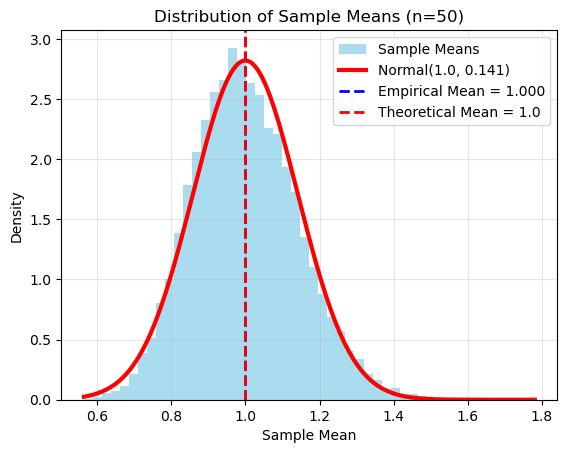

In [3]:
def single_sample_size(n=10, num_experiments=10000):
    """Demonstrate CLT for a single sample size"""
    sample_means = []
    
    print("Generating sample means...", end="")
    for i in range(num_experiments):
        # Draw n samples from exponential distribution
        sample = np.random.exponential(scale=1, size=n)
        sample_means.append(np.mean(sample))
        
        # Progress indicator
        if (i + 1) % 2000 == 0:
            print(".", end="")
    
    print(" Done!")
    
    sample_means = np.array(sample_means)
    
    # Calculate statistics
    empirical_mean = np.mean(sample_means)
    empirical_std = np.std(sample_means)
    
    # Theoretical values
    theoretical_mean = 1.0
    theoretical_std = 1.0 / np.sqrt(n)
    
    # Histogram with normal overlay
    plt.hist(sample_means, bins=50, density=True, alpha=0.7, color='skyblue',
             label='Sample Means')
    
    # Overlay theoretical normal distribution
    x = np.linspace(sample_means.min(), sample_means.max(), 200)
    normal_pdf = norm.pdf(x, theoretical_mean, theoretical_std)
    plt.plot(x, normal_pdf, 'r-', linewidth=3, 
             label=f'Normal({theoretical_mean}, {theoretical_std:.3f})')
    
    plt.axvline(empirical_mean, color='blue', linestyle='--', linewidth=2,
                label=f'Empirical Mean = {empirical_mean:.3f}')
    plt.axvline(theoretical_mean, color='red', linestyle='--', linewidth=2,
                label=f'Theoretical Mean = {theoretical_mean}')
    
    plt.title(f'Distribution of Sample Means (n={n})')
    plt.xlabel('Sample Mean')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    return sample_means

# Demo with n=10
sample_means_10 = single_sample_size(n=50)

**Key Question:** "How does the distribution change as we increase sample size?"

In [7]:
def demonstrate_clt_complete(sample_sizes_each=[5, 10, 20, 40, 80, 100], num_experiments=10000):
    """
    Complete CLT demonstration with multiple sample sizes
    
    Parameters:
    sample_sizes_each: list of sample sizes for EACH population (humans and suitcases)
    """
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    results = []
    
    for i, n_each in enumerate(sample_sizes_each):
        total_n = n_each
        
        # Generate sample means
        sample_means = []
        for _ in range(num_experiments):
            sample = np.random.exponential(scale=1, size=n_each)
            sample_means.append(np.mean(sample))
        
        sample_means = np.array(sample_means)
        
        # Calculate statistics
        empirical_mean = np.mean(sample_means)
        empirical_std = np.std(sample_means)
        theoretical_mean = 1
        
        theoretical_std = 1 / np.sqrt(total_n)
        
        results.append((n_each, total_n, empirical_mean, empirical_std, theoretical_std, abs(empirical_std - theoretical_std)))
        
        # Plot histogram
        ax = axes[i]
        ax.hist(sample_means, bins=50, density=True, alpha=0.7, color='skyblue',
                edgecolor='black', linewidth=0.5)
        
        # Overlay theoretical normal
        x = np.linspace(sample_means.min(), sample_means.max(), 200)
        normal_pdf = norm.pdf(x, theoretical_mean, theoretical_std)
        ax.plot(x, normal_pdf, 'r-', linewidth=3, label='Theoretical Normal')
        
        # Mean lines
        ax.axvline(empirical_mean, color='blue', linestyle='--', alpha=0.8,
                  label=f'Emp: {empirical_mean:.3f}')
        ax.axvline(theoretical_mean, color='red', linestyle='--', alpha=0.8,
                  label=f'Theo: {theoretical_mean}')
        
        ax.set_title(f'{total_n} samples\nσ = {empirical_std:.3f}')
        ax.set_xlabel('Sample Mean')
        ax.set_ylabel('Density')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        
    
    plt.suptitle('Central Limit Theorem: Life of Battery\nEffect of Sample Size on Distribution', 
                 fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()
    return results

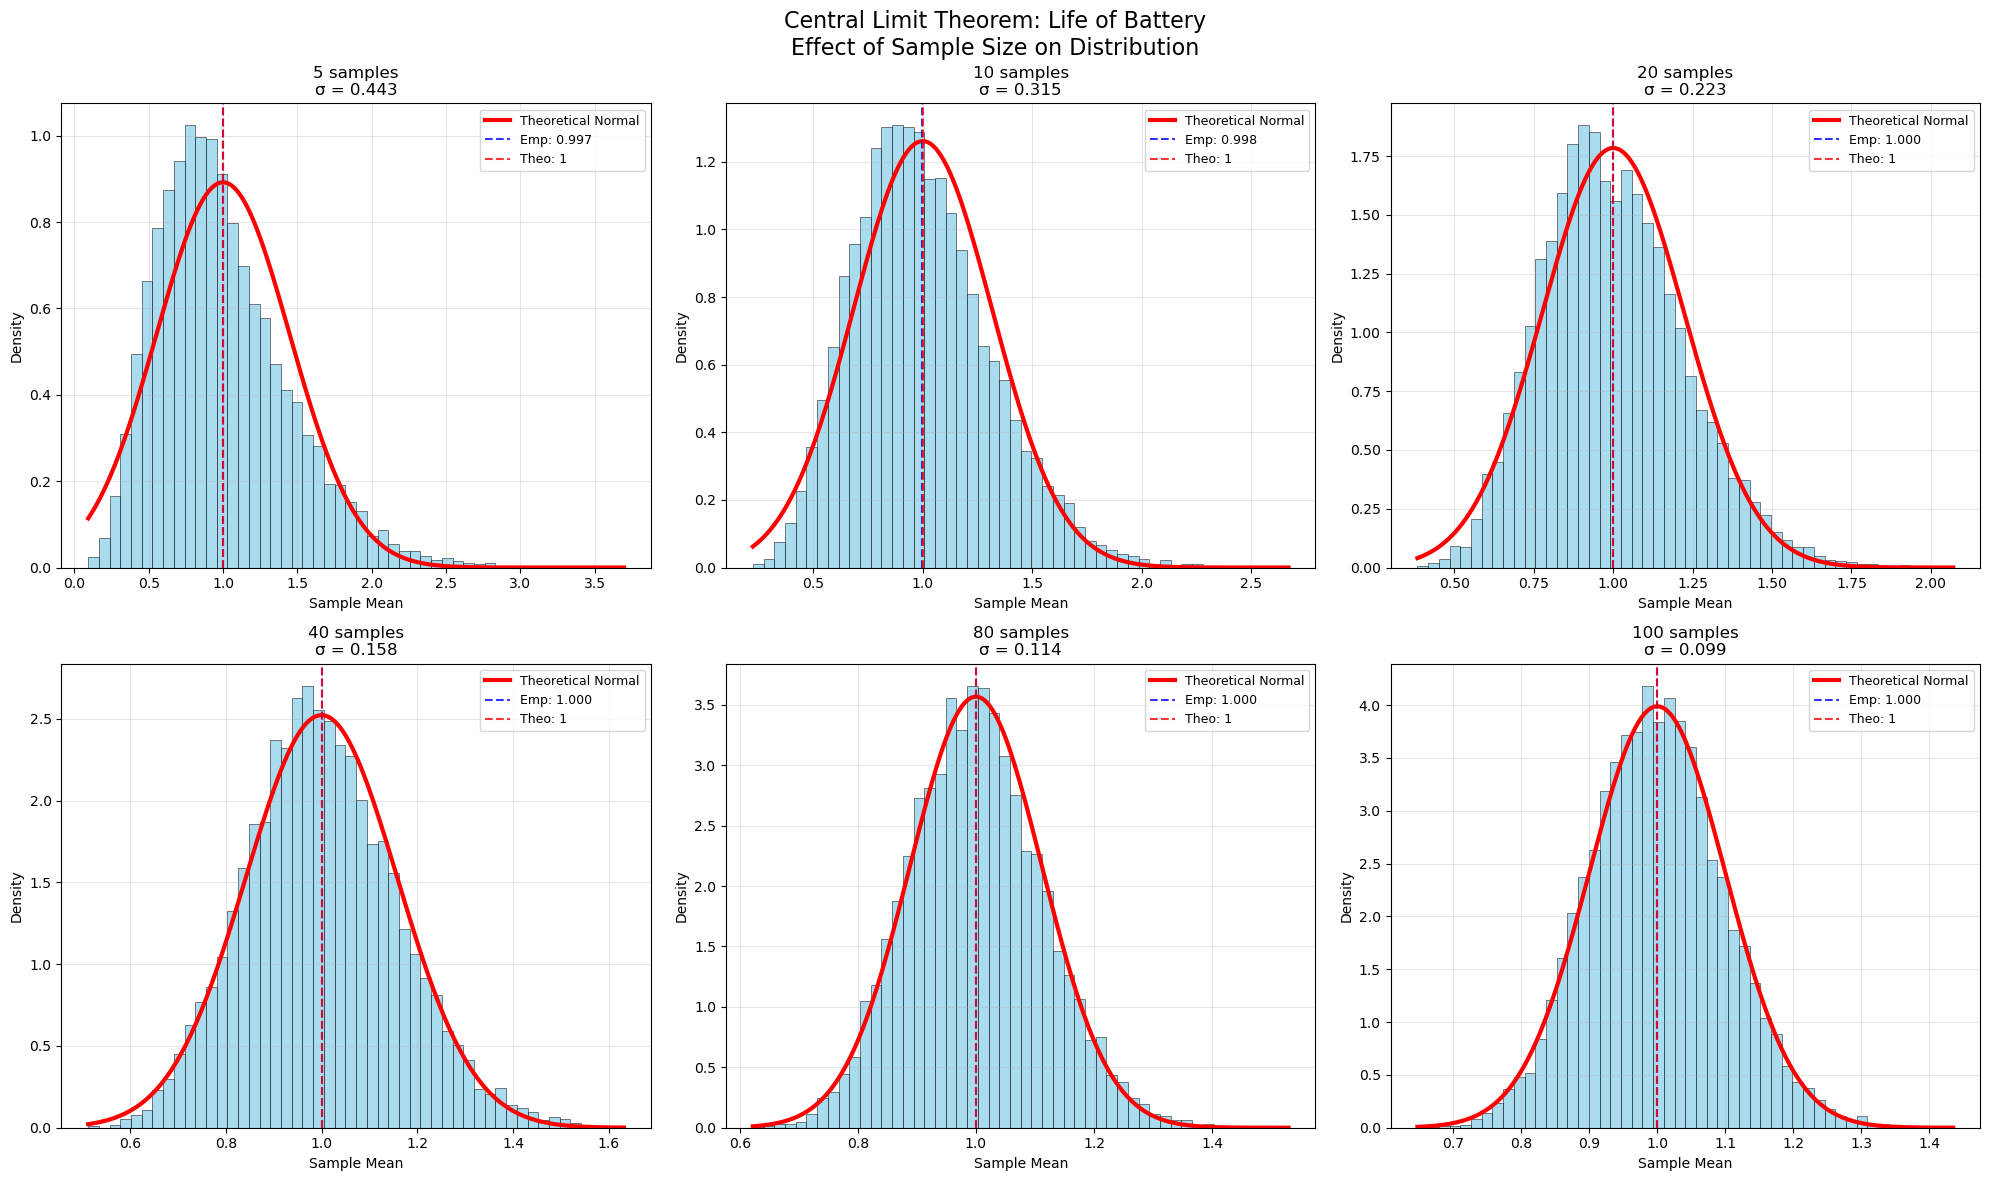

In [8]:
results = demonstrate_clt_complete()

## Problem 2

Consider a population consisting of human beings and a single suitcase taken with them as checkin baggage. Let us say that the weight of the humans are distributed normally with mean 70kgs and standard deviation 5 kgs and the bags are with mean 15 kgs and standard deviation 5 kgs. 

Now, randomly select 5 values from each of the humans and suitcases to get 10 weights. Now find the sample mean of the weights.

Repeat this sampling 10,000 times and plot the distribution (histogram) of the sample means of the humans and suitcases.

Repeat the above steps for sample sizes: 10, 20, 40, 80, 100 (i.e. 5+5, 10+10 etc. of human+suitcases).

For each sample size, overlay a normal distribution with:

Mean = 42.5

Standard deviation = 5 / √(sample size) (Why is it?)







Instead, it’s:

$\bar{X} = \tfrac{1}{2}\big(\bar{X}_{\text{human}} + \bar{X}_{\text{suitcase}}\big)$

By CLT applied separately to each group:

$\bar{X}_{\text{human}} \sim N(70, \tfrac{25}{n}),
\quad
\bar{X}_{\text{suitcase}} \sim N(15, \tfrac{25}{n})$

These are independent. Averaging gives:

$
\bar{X} \sim N\!\left(42.5, \tfrac{25}{2n}\right)
$

In [13]:
human_mean, human_std = 70, 5
bag_mean, bag_std = 15, 5

n_humans = 5
n_bags = 5

human_samples = np.random.normal(loc=human_mean, scale=human_std, size=n_humans)
bag_samples = np.random.normal(loc=bag_mean, scale=bag_std, size=n_bags)

# Combine into one array
all_samples = np.concatenate([human_samples, bag_samples])

# Compute sample mean
sample_mean = all_samples.mean()

print(sample_mean)

42.62456695203676


In [14]:
def single_sample_size(n_each=5, num_experiments=10000):
    """
    single sample size with human+suitcase weights
    
    Parameters:
    n_each: number of humans AND suitcases (total sample size = 2*n_each)
    num_experiments: number of sampling experiments
    """
    total_sample_size = 2 * n_each
    sample_means = []
    
    print("Generating sample means...", end="")
    for i in range(num_experiments):
        # Sample from both populations
        human_sample = np.random.normal(70, 5, n_each)
        suitcase_sample = np.random.normal(15, 5, n_each)
        
        # Combine samples and calculate mean
        combined_sample = np.concatenate([human_sample, suitcase_sample])
        sample_means.append(np.mean(combined_sample))
        
        # Progress indicator
        if (i + 1) % 2000 == 0:
            print(".", end="")
    
    print(" Done!")
    
    sample_means = np.array(sample_means)
    
    # Calculate statistics
    empirical_mean = np.mean(sample_means)
    empirical_std = np.std(sample_means)
    
    # Theoretical values
    theoretical_mean = 42.5
    theoretical_std = 5 / np.sqrt(total_sample_size)
    
    
    # Histogram with normal overlay
    plt.hist(sample_means, bins=50, density=True, alpha=0.7, color='lightgreen',
             label='Sample Means')
    
    # Overlay theoretical normal distribution
    x = np.linspace(sample_means.min(), sample_means.max(), 200)
    normal_pdf = norm.pdf(x, theoretical_mean, theoretical_std)
    plt.plot(x, normal_pdf, 'r-', linewidth=3, 
             label=f'N(42.5, {theoretical_std:.3f})')
    
    plt.axvline(empirical_mean, color='green', linestyle='--', linewidth=2,
                label=f'Empirical Mean = {empirical_mean:.3f}')
    plt.axvline(theoretical_mean, color='red', linestyle='--', linewidth=2,
                label=f'Theoretical Mean = 42.5')
    
    plt.title(f'Sample Means Distribution\n({n_each}+{n_each} = {total_sample_size} weights)')
    plt.xlabel('Sample Mean (kg)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    
    return sample_means

Generating sample means........ Done!


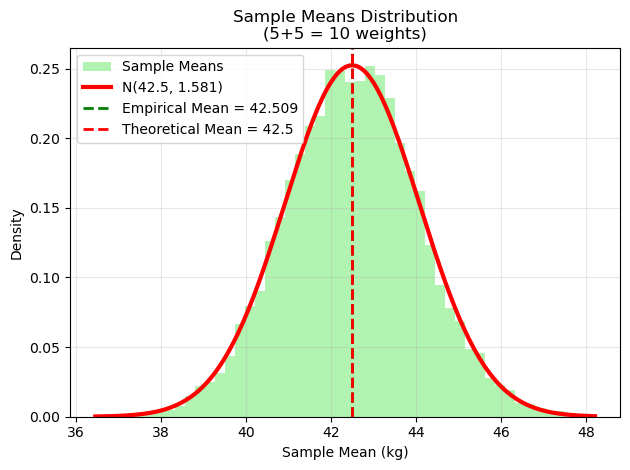

In [15]:
sample_means_5 = single_sample_size(n_each=5)

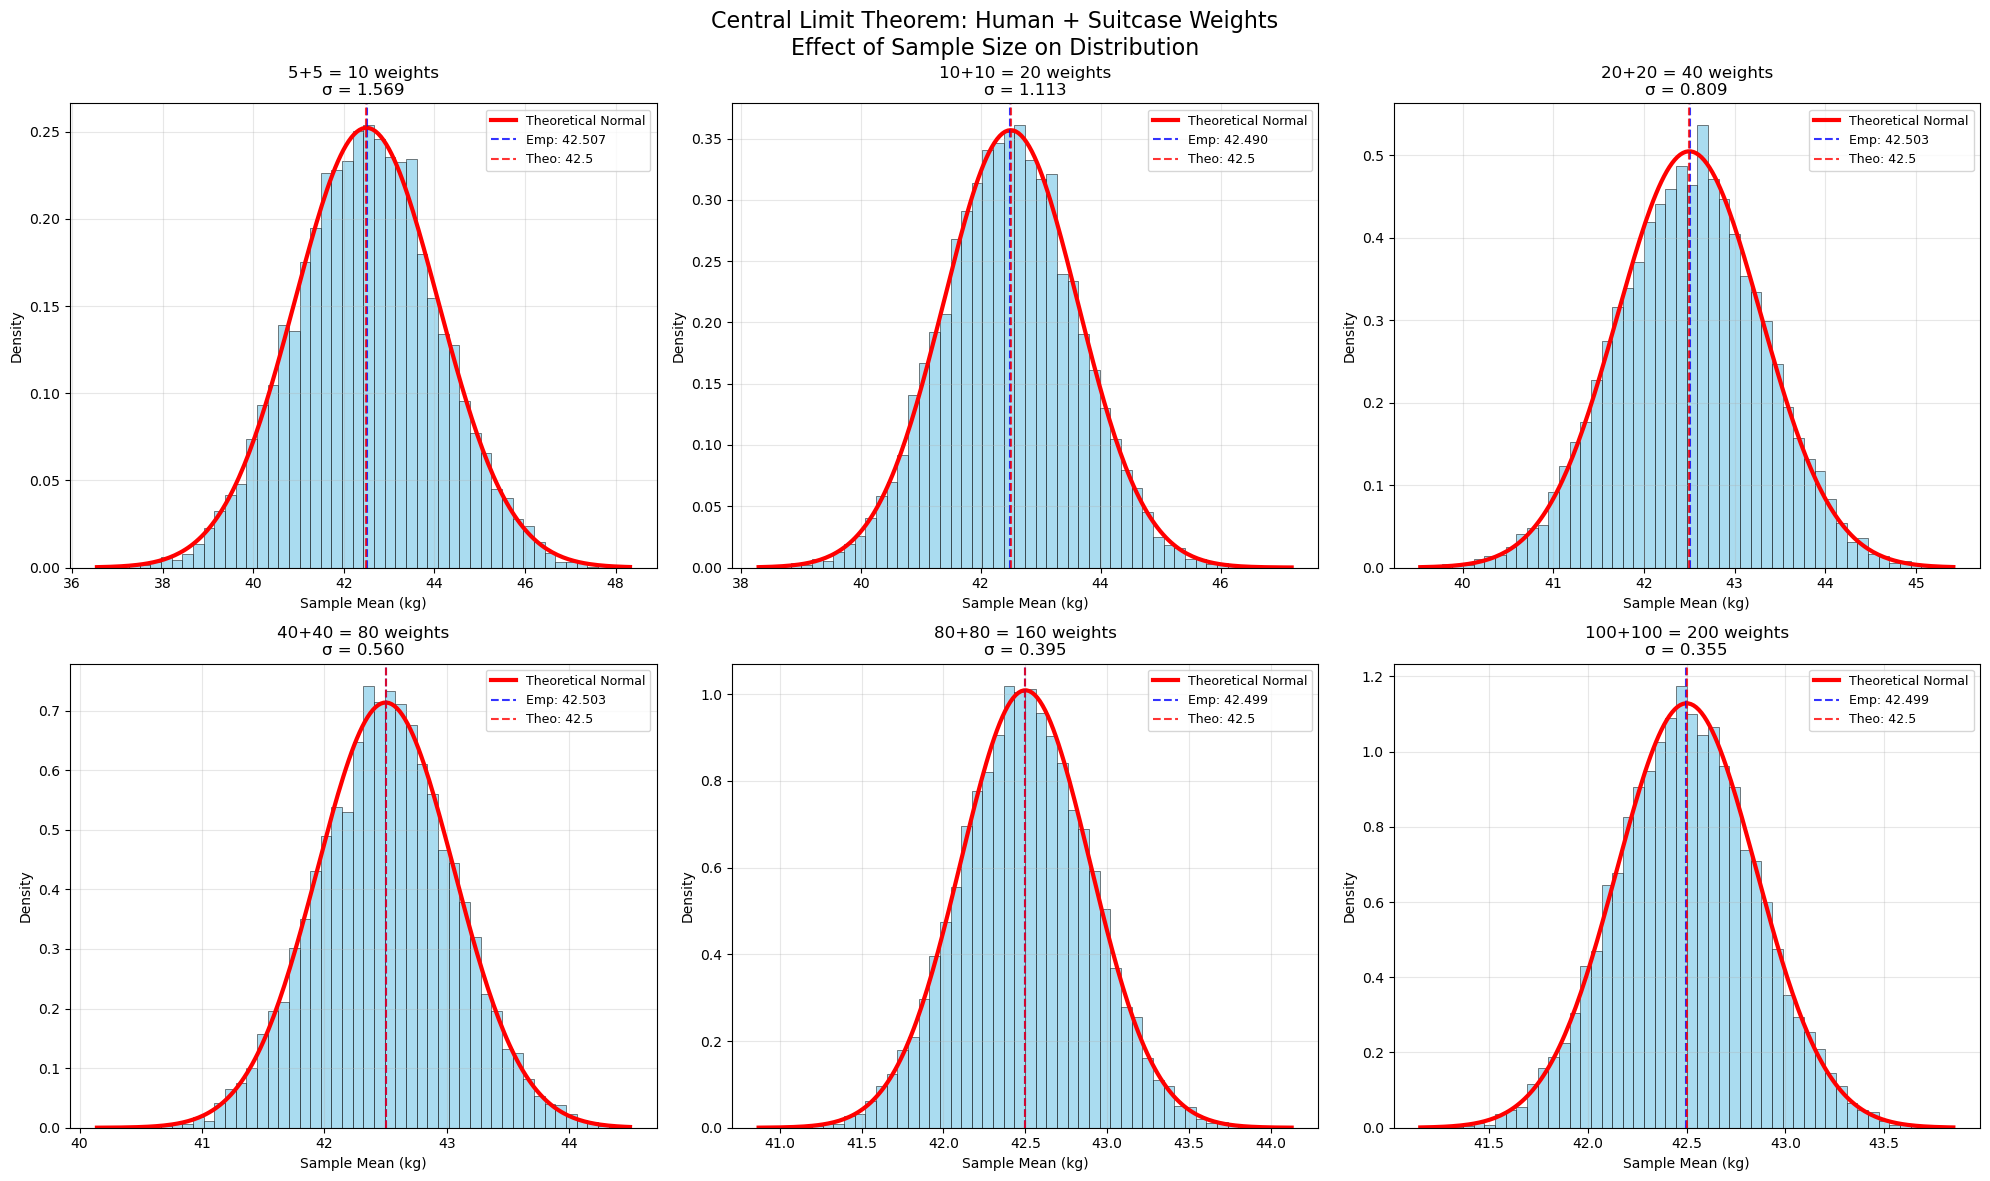

In [11]:
def demonstrate_clt_complete(sample_sizes_each=[5, 10, 20, 40, 80, 100], num_experiments=10000):
    """
    Complete CLT demonstration with multiple sample sizes
    
    Parameters:
    sample_sizes_each: list of sample sizes for EACH population (humans and suitcases)
    """
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    results = []
    
    for i, n_each in enumerate(sample_sizes_each):
        total_n = 2 * n_each
        
        # Generate sample means
        sample_means = []
        for _ in range(num_experiments):
            human_sample = np.random.normal(70, 5, n_each)
            suitcase_sample = np.random.normal(15, 5, n_each)
            combined_sample = np.concatenate([human_sample, suitcase_sample])
            sample_means.append(np.mean(combined_sample))
        
        sample_means = np.array(sample_means)
        
        # Calculate statistics
        empirical_mean = np.mean(sample_means)
        empirical_std = np.std(sample_means)
        theoretical_mean = 42.5
        
        theoretical_std = 5 / np.sqrt(total_n)
        
        results.append((n_each, total_n, empirical_mean, empirical_std, theoretical_std, abs(empirical_std - theoretical_std)))
        
        # Plot histogram
        ax = axes[i]
        ax.hist(sample_means, bins=50, density=True, alpha=0.7, color='skyblue',
                edgecolor='black', linewidth=0.5)
        
        # Overlay theoretical normal
        x = np.linspace(sample_means.min(), sample_means.max(), 200)
        normal_pdf = norm.pdf(x, theoretical_mean, theoretical_std)
        ax.plot(x, normal_pdf, 'r-', linewidth=3, label='Theoretical Normal')
        
        # Mean lines
        ax.axvline(empirical_mean, color='blue', linestyle='--', alpha=0.8,
                  label=f'Emp: {empirical_mean:.3f}')
        ax.axvline(theoretical_mean, color='red', linestyle='--', alpha=0.8,
                  label=f'Theo: {theoretical_mean}')
        
        ax.set_title(f'{n_each}+{n_each} = {total_n} weights\nσ = {empirical_std:.3f}')
        ax.set_xlabel('Sample Mean (kg)')
        ax.set_ylabel('Density')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Central Limit Theorem: Human + Suitcase Weights\nEffect of Sample Size on Distribution', 
                 fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()
    
    return results
# Run demonstration
results = demonstrate_clt_complete()